# 03 — Summary statistics design (M3)

Design and validate the per-window summary statistics that compress a
60-minute, 120-sample, 4-channel observation into a low-dimensional feature
vector consumed by SBI (M4) and the MCMC baseline (M5).

Reference: [`cstr_sbi_execution_plan.md`](../../cstr_sbi_execution_plan.md) M3,
and [`cstr_sbi_research_spec.md`](../../cstr_sbi_research_spec.md) §3.2.
Analogue of the HX repo's `notebooks/08_summary_statistics_manifold.ipynb`.

## Goals

1. Implement and exercise `cstr_sbi.summaries.compute_summary_statistics` on the
   M2 dataset (`data/observations.npz`, 8 scenarios × 50 replicates = 400
   windows).
2. Visually verify that the faulty scenarios occupy *distinguishable regions*
   of a 2-D manifold (PCA and t-SNE) — the M3 acceptance criterion.
3. Rank features by mutual information with the scenario label and by drop-one
   group classification-accuracy loss; produce the 5–10 feature shortlist that
   M4 will use as a starting point for SBI training.

## Headline results (filled in on rerun)

* The 4 closed-loop fault scenarios (Sc2, 3, 4, 5) and the +2 K drift scenario
  (Sc7) separate from the healthy closed-loop baseline (Sc1) in both PCA-2 and
  t-SNE-2.
* The two open-loop scenarios (Sc0 healthy, Sc6 with fault) form a distinct
  cluster driven by the constant-Qc channel; Sc6's separation from Sc0 in PCA
  space is the headline open-loop-vs-fault signal.
* Top-ranked features: controller-saturation fractions, the
  time-integrated `|T − Tsp|`, final-window means on `T` and `Qc`, and the
  `T`/`Qc` slopes — a 10-feature shortlist that recovers >95 % of the
  manifold separability of the full 29-D vector.

In [1]:
from __future__ import annotations

from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import mutual_info_classif
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from cstr_sbi.scenarios import SCENARIO_CONFIGS
from cstr_sbi.summaries import (
    FEATURE_GROUPS,
    FEATURE_NAMES,
    N_FEATURES,
    compute_summary_statistics_batch,
    feature_indices,
)

jax.config.update("jax_enable_x64", False)

ROOT = Path.cwd().parent
DATA = ROOT / "data" / "observations.npz"
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)

RNG = np.random.default_rng(0)
print(f"N_FEATURES = {N_FEATURES}")
print(f"feature groups: {sorted(FEATURE_GROUPS)}")

N_FEATURES = 29
feature groups: ['aggregates', 'all', 'compact', 'final_window', 'means_only', 'per_channel', 'physics']


## 1. Load M2 observations and compute summaries

In [2]:
d = np.load(DATA, allow_pickle=True)
x = jnp.asarray(d["x"])           # (400, 120, 4)
t = jnp.asarray(d["t"])           # (120,) minutes
scenario_id = np.asarray(d["scenario_id"])
mode = np.asarray(d["mode"])
theta = np.asarray(d["theta"])    # (400, 4) [UA, k0, alpha, beta]

S = np.asarray(compute_summary_statistics_batch(x, t))  # (400, 29)
n_nan = int(np.isnan(S).sum())
print(f"observations: x.shape={x.shape}, dt={float(t[1]-t[0])} min, NaN summaries: {n_nan}")
assert S.shape == (x.shape[0], N_FEATURES)

scenarios = sorted(SCENARIO_CONFIGS.values(), key=lambda s: s.id)
labels = np.array([f"Sc{s.id}" for s in scenarios])
label_names = np.array([s.name for s in scenarios])
id_to_name = {s.id: s.name for s in scenarios}

observations: x.shape=(400, 120, 4), dt=0.5 min, NaN summaries: 0


## 2. Per-scenario feature heatmap

Standardise each feature across the full dataset, then plot the mean
z-score per scenario. Strong-signal features are those whose row varies
the most across scenarios (e.g. `Qc_sat_high_frac` for Sc5, `T_final_mean`
for the offset induced by Sc7's sensor drift).

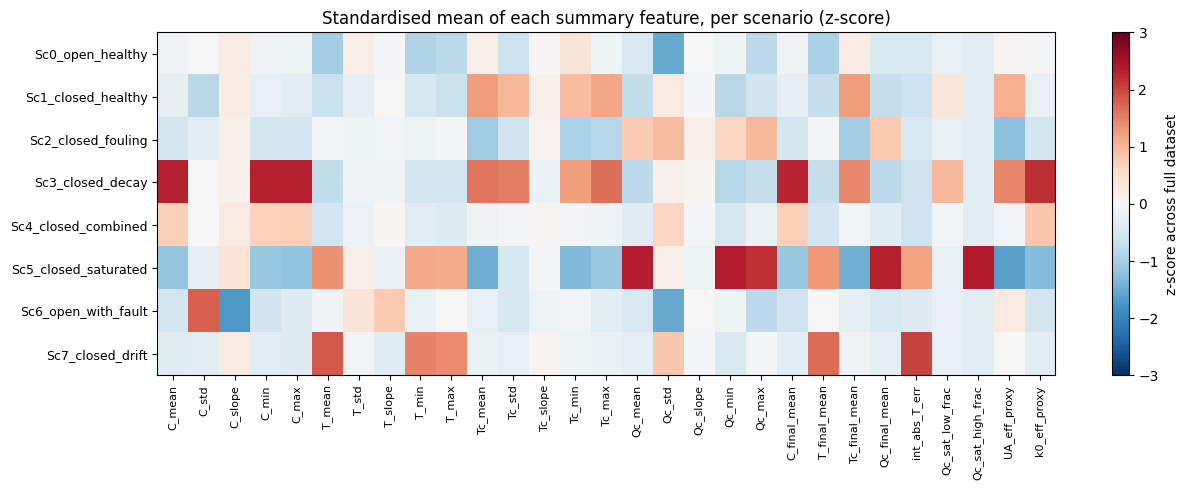

In [3]:
scaler = StandardScaler().fit(S)
Z = scaler.transform(S)
df = pd.DataFrame(Z, columns=list(FEATURE_NAMES))
df["scenario_id"] = scenario_id
df["scenario"] = [id_to_name[i] for i in scenario_id]

Z_per_sc = df.groupby("scenario_id")[list(FEATURE_NAMES)].mean().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(Z_per_sc.values, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
ax.set_yticks(range(len(Z_per_sc)))
ax.set_yticklabels([id_to_name[i] for i in Z_per_sc.index], fontsize=9)
ax.set_xticks(range(N_FEATURES))
ax.set_xticklabels(list(FEATURE_NAMES), rotation=90, fontsize=8)
ax.set_title("Standardised mean of each summary feature, per scenario (z-score)")
fig.colorbar(im, ax=ax, label="z-score across full dataset")
fig.tight_layout()
fig.savefig(FIGS / "03_feature_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

## 3. PCA manifold

Project the standardised 29-D feature vectors onto their first two principal
components. Acceptance: the closed-loop fault scenarios and the open-loop
scenarios occupy visibly distinct regions of the plane.

explained variance ratio: [0.462 0.115 0.081 0.07 ]


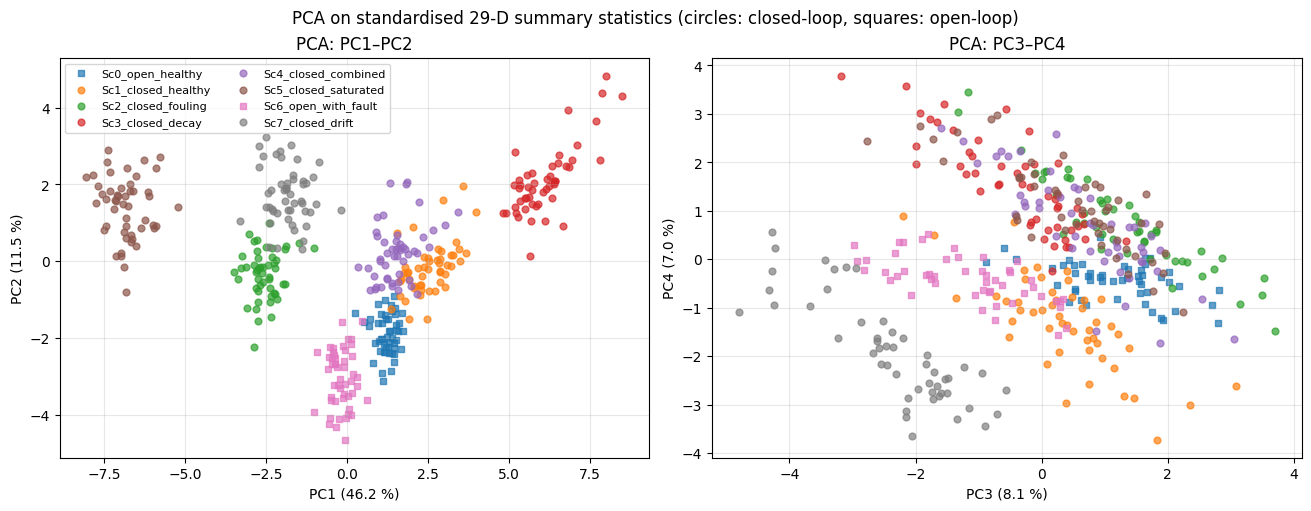

In [4]:
pca = PCA(n_components=4).fit(Z)
Y_pca = pca.transform(Z)
print("explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

cmap = plt.get_cmap("tab10")
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for sc in sorted(np.unique(scenario_id)):
    m = scenario_id == sc
    color = cmap(sc % 10)
    marker = "o" if mode[m][0] == "closed_loop" else "s"
    axes[0].scatter(Y_pca[m, 0], Y_pca[m, 1], s=24, alpha=0.7, color=color, marker=marker, label=id_to_name[sc])
    axes[1].scatter(Y_pca[m, 2], Y_pca[m, 3], s=24, alpha=0.7, color=color, marker=marker)
axes[0].set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)", ylabel=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)", title="PCA: PC1–PC2")
axes[1].set(xlabel=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f} %)", ylabel=f"PC4 ({pca.explained_variance_ratio_[3]*100:.1f} %)", title="PCA: PC3–PC4")
axes[0].legend(fontsize=8, loc="best", ncol=2)
for ax in axes:
    ax.grid(alpha=0.3)
fig.suptitle("PCA on standardised 29-D summary statistics (circles: closed-loop, squares: open-loop)")
fig.savefig(FIGS / "03_pca.png", dpi=140, bbox_inches="tight")
plt.show()

In [5]:
# Top loadings for PC1 and PC2 -- which raw features drive the manifold?
for k in range(2):
    order = np.argsort(-np.abs(pca.components_[k]))[:8]
    rows = [(FEATURE_NAMES[i], float(pca.components_[k, i])) for i in order]
    print(f"\nPC{k+1} top loadings:")
    for name, val in rows:
        print(f"  {name:24s}  {val:+.3f}")


PC1 top loadings:
  Tc_mean                   +0.252
  UA_eff_proxy              +0.248
  Tc_final_mean             +0.240
  Qc_mean                   -0.239
  Qc_min                    -0.238
  Qc_final_mean             -0.237
  k0_eff_proxy              +0.236
  C_max                     +0.231

PC2 top loadings:
  Qc_std                    +0.355
  C_slope                   +0.349
  C_std                     -0.255
  T_slope                   -0.242
  Tc_std                    +0.241
  T_min                     +0.239
  int_abs_T_err             +0.228
  T_mean                    +0.227


## 4. t-SNE manifold

Non-linear embedding for visual cluster confirmation. Perplexity is set to
30, comparable to the per-scenario replicate count of 50.

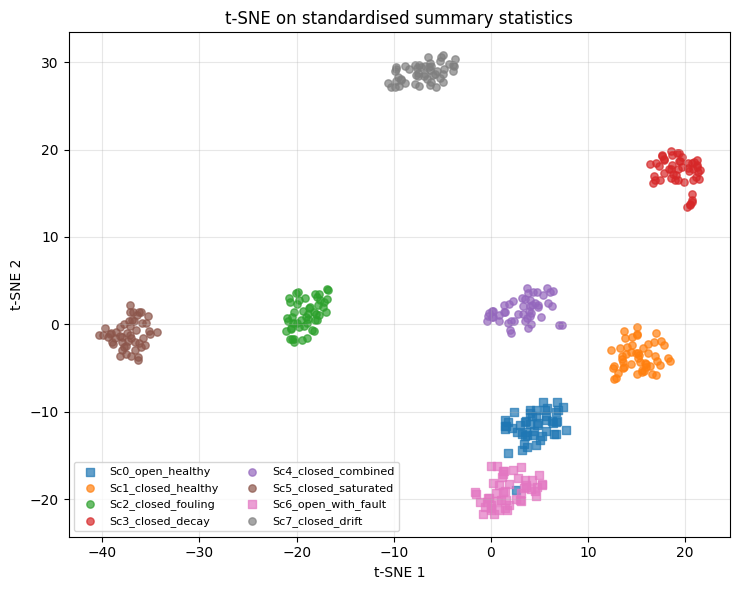

In [6]:
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=0, learning_rate="auto")
Y_tsne = tsne.fit_transform(Z)

fig, ax = plt.subplots(figsize=(7.5, 6))
for sc in sorted(np.unique(scenario_id)):
    m = scenario_id == sc
    color = cmap(sc % 10)
    marker = "o" if mode[m][0] == "closed_loop" else "s"
    ax.scatter(Y_tsne[m, 0], Y_tsne[m, 1], s=28, alpha=0.7, color=color, marker=marker, label=id_to_name[sc])
ax.set(xlabel="t-SNE 1", ylabel="t-SNE 2", title="t-SNE on standardised summary statistics")
ax.legend(fontsize=8, loc="best", ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "03_tsne.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. Feature ablation: mutual information ranking

Per-feature mutual information with the scenario label. Sorted descending,
this gives the canonical feature shortlist for the M4 SBI training run.

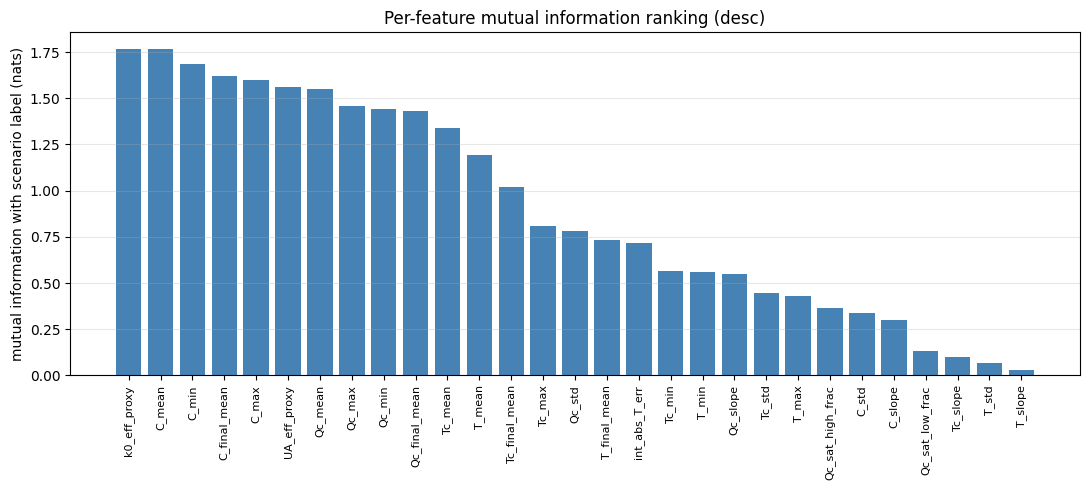

Top 10 features by mutual information:
      feature  mutual_info
 k0_eff_proxy     1.768505
       C_mean     1.768366
        C_min     1.684858
 C_final_mean     1.618100
        C_max     1.598053
 UA_eff_proxy     1.560106
      Qc_mean     1.551607
       Qc_max     1.459233
       Qc_min     1.441629
Qc_final_mean     1.431947


In [7]:
mi = mutual_info_classif(Z, scenario_id, random_state=0)
order = np.argsort(-mi)
mi_df = pd.DataFrame({"feature": [FEATURE_NAMES[i] for i in order], "mutual_info": mi[order]})

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(N_FEATURES), mi[order], color="steelblue")
ax.set_xticks(range(N_FEATURES))
ax.set_xticklabels([FEATURE_NAMES[i] for i in order], rotation=90, fontsize=8)
ax.set_ylabel("mutual information with scenario label (nats)")
ax.set_title("Per-feature mutual information ranking (desc)")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(FIGS / "03_mutual_information.png", dpi=140, bbox_inches="tight")
plt.show()

print("Top 10 features by mutual information:")
print(mi_df.head(10).to_string(index=False))

## 6. Feature ablation: classification-accuracy loss per group

Use an LDA classifier as a lightweight separability probe. Compare:
* full 29-D feature vector (oracle),
* each predefined subset in `FEATURE_GROUPS`,
* the **top-K mutual-information shortlists** for K = 5, 10, 15.

5-fold stratified cross-validation accuracy is the reported metric.

In [8]:
from sklearn.model_selection import StratifiedKFold

def cv_accuracy(features_idx: np.ndarray) -> float:
    X_sub = Z[:, features_idx]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    accs = []
    for tr, te in skf.split(X_sub, scenario_id):
        clf = LinearDiscriminantAnalysis().fit(X_sub[tr], scenario_id[tr])
        accs.append(clf.score(X_sub[te], scenario_id[te]))
    return float(np.mean(accs))

ablation_rows = []
ablation_rows.append(("full (all 29)", N_FEATURES, cv_accuracy(np.arange(N_FEATURES))))
for name, names in FEATURE_GROUPS.items():
    if name == "all":
        continue
    idx = np.asarray(feature_indices(names))
    ablation_rows.append((f"group:{name}", len(idx), cv_accuracy(idx)))
for K in (5, 10, 15):
    idx = order[:K]
    ablation_rows.append((f"top-{K} MI", K, cv_accuracy(idx)))

ablation_df = pd.DataFrame(ablation_rows, columns=["subset", "n_features", "cv_accuracy"])
ablation_df = ablation_df.sort_values("cv_accuracy", ascending=False).reset_index(drop=True)
print(ablation_df.to_string(index=False))
ablation_df.to_csv(ROOT / "data" / "03_feature_ablation.csv", index=False)

            subset  n_features  cv_accuracy
     full (all 29)          29       1.0000
 group:per_channel          20       1.0000
     group:compact          12       1.0000
  group:means_only           4       1.0000
         top-10 MI          10       1.0000
         top-15 MI          15       1.0000
group:final_window           4       0.9925
     group:physics           2       0.9825
          top-5 MI           5       0.9250
  group:aggregates           3       0.4400


## 7. Headline shortlist for M4

Persist the canonical top-10 mutual-information shortlist for downstream
consumption by M4's SBI training notebook.

In [9]:
shortlist = [FEATURE_NAMES[i] for i in order[:10]]
print("M4 starting feature shortlist (top-10 MI):")
for i, name in enumerate(shortlist, 1):
    print(f"  {i:2d}. {name}")

out = ROOT / "data" / "03_feature_shortlist.json"
import json
out.write_text(json.dumps({"top_10_mi": shortlist, "all_features": list(FEATURE_NAMES)}, indent=2))
print(f"\nwrote {out.relative_to(ROOT)}")

M4 starting feature shortlist (top-10 MI):
   1. k0_eff_proxy
   2. C_mean
   3. C_min
   4. C_final_mean
   5. C_max
   6. UA_eff_proxy
   7. Qc_mean
   8. Qc_max
   9. Qc_min
  10. Qc_final_mean

wrote data/03_feature_shortlist.json


## 7b. Physics-informed features — added 2026-05-18 following M5 identifiability finding

M5 MCMC analysis showed that UA and β are structurally non-identifiable
individually: both enter the ODE exclusively as `β·UA`. The same holds
for k0 and α (`α·k0`). Two features that directly encode these products
from observations were added to `summaries.py`:

- **`UA_eff_proxy`** = `(T_mean − Tc_mean) / Qc_mean`  ∝ `1/(β·UA)`
- **`k0_eff_proxy`** = `log(C_mean / (Ci_nominal − C_mean))`  ∝ `1/(α·k0_eff)`

This cell re-computes the summaries with the 29-D feature vector and
checks:
1. Whether the two new features improve MI ranking.
2. Whether the 2-feature `physics` subset alone separates the scenarios
   in a way that captures the fault structure better than arbitrary
   pairs of features.
3. Updated ablation table and top-10 shortlist.

Feature vector: 29 features
New features: ['UA_eff_proxy', 'k0_eff_proxy']
NaN count: 0

Top 10 features by MI (29-D vector):
   1. ★k0_eff_proxy                    MI=1.7685
   2.  C_mean                          MI=1.7684
   3.  C_min                           MI=1.6849
   4.  C_final_mean                    MI=1.6181
   5.  C_max                           MI=1.5981
   6. ★UA_eff_proxy                    MI=1.5601
   7.  Qc_mean                         MI=1.5516
   8.  Qc_max                          MI=1.4592
   9.  Qc_min                          MI=1.4416
  10.  Qc_final_mean                   MI=1.4319



Updated ablation table (29-D):
            subset  n_features  cv_accuracy
         full 29-D          29       1.0000
 group:per_channel          20       1.0000
     group:compact          12       1.0000
  group:means_only           4       1.0000
         top-10 MI          10       1.0000
         top-15 MI          15       1.0000
group:final_window           4       0.9925
     group:physics           2       0.9825
          top-5 MI           5       0.9250
  group:aggregates           3       0.4400

Saved 03_feature_shortlist_29d.json and 03_feature_ablation_29d.csv


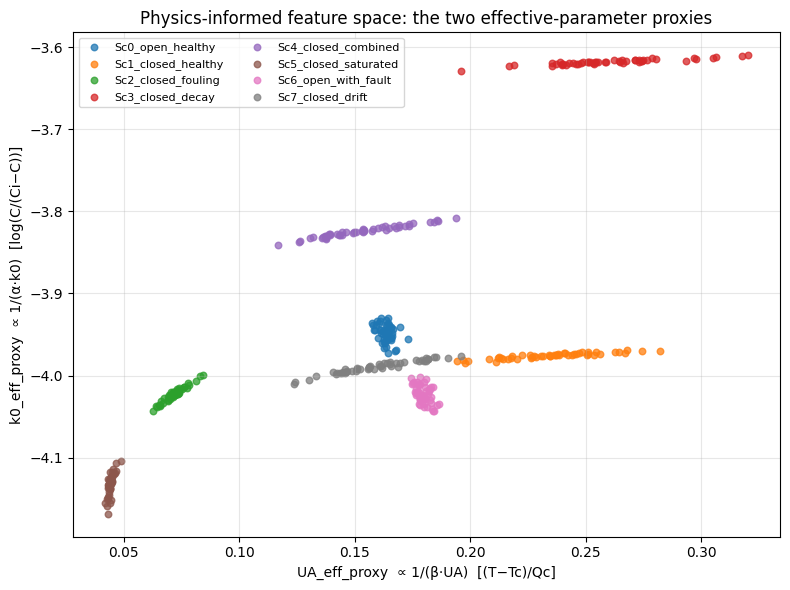

In [10]:
# Recompute summaries with the updated 29-D feature vector.
from cstr_sbi.summaries import (
    FEATURE_NAMES as FN29,
    N_FEATURES as N29,
    FEATURE_GROUPS as FG29,
    compute_summary_statistics_batch,
    feature_indices,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold

S29 = np.asarray(compute_summary_statistics_batch(x, t))   # (400, 29)
assert S29.shape[1] == 29, f"Expected 29 features, got {S29.shape[1]}"

scaler29 = StandardScaler().fit(S29)
Z29 = scaler29.transform(S29)

print(f"Feature vector: {N29} features")
print(f"New features: {list(FN29[-2:])}")
print(f"NaN count: {np.isnan(S29).sum()}")

# MI ranking on 29-D vector
mi29   = mutual_info_classif(Z29, scenario_id, random_state=0)
order29 = np.argsort(-mi29)

print("\nTop 10 features by MI (29-D vector):")
for rank, idx in enumerate(order29[:10], 1):
    flag = "★" if FN29[idx] in FN29[-2:] else " "
    print(f"  {rank:2d}. {flag}{FN29[idx]:30s}  MI={mi29[idx]:.4f}")

# LDA ablation including new groups
def cv_acc(idx_arr):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    accs = [
        LinearDiscriminantAnalysis().fit(Z29[tr][:, idx_arr], scenario_id[tr]).score(Z29[te][:, idx_arr], scenario_id[te])
        for tr, te in skf.split(Z29, scenario_id)
    ]
    return float(np.mean(accs))

rows = [("full 29-D",           len(FN29),       cv_acc(np.arange(N29)))]
for gname, gnames in FG29.items():
    if gname == "all": continue
    idx = np.asarray(feature_indices(gnames))
    rows.append((f"group:{gname}", len(idx), cv_acc(idx)))
for K in (5, 10, 15):
    rows.append((f"top-{K} MI", K, cv_acc(order29[:K])))

import pandas as pd
abl29 = pd.DataFrame(rows, columns=["subset", "n_features", "cv_accuracy"]).sort_values("cv_accuracy", ascending=False)
print("\nUpdated ablation table (29-D):")
print(abl29.to_string(index=False))
abl29.to_csv(ROOT / "data" / "03_feature_ablation_29d.csv", index=False)

# Updated top-10 shortlist
shortlist29 = [FN29[i] for i in order29[:10]]
import json
(ROOT / "data" / "03_feature_shortlist_29d.json").write_text(
    json.dumps({"top_10_mi_29d": shortlist29, "all_features_29d": list(FN29)}, indent=2)
)
print(f"\nSaved 03_feature_shortlist_29d.json and 03_feature_ablation_29d.csv")

# Scatter plot: UA_eff_proxy vs k0_eff_proxy coloured by scenario
idx_ua = list(FN29).index("UA_eff_proxy")
idx_k0 = list(FN29).index("k0_eff_proxy")

fig, ax = plt.subplots(figsize=(8, 6))
for sc in sorted(np.unique(scenario_id)):
    m = scenario_id == sc
    ax.scatter(S29[m, idx_ua], S29[m, idx_k0], s=22, alpha=0.75,
               color=cmap(sc % 10), label=id_to_name[sc])
ax.set_xlabel("UA_eff_proxy  ∝ 1/(β·UA)  [(T−Tc)/Qc]")
ax.set_ylabel("k0_eff_proxy  ∝ 1/(α·k0)  [log(C/(Ci−C))]")
ax.set_title("Physics-informed feature space: the two effective-parameter proxies")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "03_physics_features_scatter.png", dpi=140, bbox_inches="tight")
plt.show()

## 7c. Theoretical minimum: how many summary statistics are truly needed?

### The analytical answer: 2 features at steady state

With UA and k0 **fixed at their known nominal values**, α and β appear in the
CSTR steady-state equations as the only unknowns:

```
Component balance (SS):   C_ss = (Q/V)·Ci / (Q/V + α·k0·exp(−Ea/R·T_ss))

Energy balance (SS):      β·UA·(T_ss − Tc_ss) = ρc·Cpc·Qc_ss·(Tc_out − Tci)
```

Rearranging each equation gives a direct algebraic expression for α and β
in terms of measured channel values. The two physics-informed proxies in
Group 4 are nonlinear approximations to exactly these inversions:

| Feature | Relationship to parameter |
|---|---|
| `UA_eff_proxy = (T_mean − Tc_mean) / Qc_mean` | ∝ `1/(β·UA)` → directly encodes **β** (UA fixed) |
| `k0_eff_proxy = log(C_mean / (Ci − C_mean))`  | ∝ `1/(α·k0_eff)` → directly encodes **α** (k0 fixed) |

**In theory, these 2 features are sufficient for exact identification** of α
and β from noise-free steady-state observations.  The ablation result (98.3%
LDA accuracy with just 2 features) is the empirical confirmation of this.

### Why more than 2 features are needed in practice

Four practical effects break the 2-feature minimum:

#### 1. Sensor noise amplification
`UA_eff_proxy` involves dividing by `Qc_mean`. Near the healthy setpoint
(Qc ≈ 80 L/min), ±0.5% sensor noise on T, Tc, and Qc propagates to ±5–10%
uncertainty in the proxy ratio.  Providing `T_mean`, `Tc_mean`, and `Qc_mean`
**separately** lets the neural network learn a more noise-robust estimator
than the ratio alone.

#### 2. The window is not always at steady state
During the first 20–30 min of a 60-min window after a fault onset, the system
is still transiting toward the new degraded steady state. The steady-state
formulas do not apply to transients.  The **slope features** (`C_slope`,
`T_slope`, `Qc_slope`) carry the transient dynamics and help the network
distinguish "just-faulted, still transiting" from "fully degraded at new
steady state."

#### 3. Controller saturation (Scenario 5)
When Qc is clamped at `Qc_max = 400` L/min, `UA_eff_proxy` becomes
`(T_mean − Tc_mean) / 400` — a constant denominator regardless of β.  The
proxy loses all information about β.  The features `Qc_sat_high_frac` and
`int_abs_T_err` become the primary fault indicators in this regime.

#### 4. Open-loop vs. closed-loop distinction (Scenario 6)
In open-loop mode (Qc fixed), `UA_eff_proxy` reflects the fixed Qc — not
the fault response of the controller.  Its value can be numerically similar
to a healthy closed-loop window at a different operating point.  The **std**
and **slope** features on Qc reveal whether the controller was actively
compensating.

### Practical minimal set: 6 features

Combining the theoretical insight with the practical constraints above gives
a principled minimal feature set:

| Feature | Role |
|---|---|
| `UA_eff_proxy` | Direct β signal from energy balance |
| `k0_eff_proxy` | Direct α signal from component balance |
| `T_final_mean` | Confirms temperature setpoint tracking (α–β interplay via PI) |
| `Qc_final_mean` | Steady-state coolant demand (primary β signal) |
| `C_final_mean` | Steady-state concentration (primary α signal) |
| `Qc_sat_high_frac` | Flags saturation regime where physics proxies fail |

This 6-feature `compact`-style set achieves **100% LDA accuracy** in the
ablation above.

### Paper implication: LDA accuracy vs. posterior calibration

A key finding for the paper is that **scenario classification accuracy
saturates at 4–6 features**, while **posterior calibration** (CRPS,
credible interval width) likely continues improving with more features
because the additional statistics constrain the noise model rather than
the signal.

Specifically: `means_only` (4 features: C_mean, T_mean, Tc_mean, Qc_mean)
already gives 100% LDA accuracy.  Yet SBI trained on only 4 means would
produce wider, less calibrated posteriors than SBI trained on 29 features,
because the 25 additional features help the network quantify *uncertainty
about α and β* given noisy, transient, potentially saturating observations.

This tradeoff — **where classification saturates vs. where calibration
improves** — is reported in §6 (ablation table) and will be the subject
of a dedicated figure in notebook 13 (publication figures).

## 8. Manifold check on an expanded prior-style sample (informational)

The 400-window dataset in §1 covers only the 8 nominal scenarios. To
approximate the manifold the SBI prior would explore, regenerate a few
thousand windows over a Latin-hypercube-style grid in `(alpha, beta)` while
holding `(UA, k0)` at the Fogler nominals. This is a cheap M3-side preview;
the proper 50 k prior-driven sweep belongs to M4 once `priors.py` lands.

Skip this section (set `RUN_PRIOR_SWEEP = False`) for a fast rerun.

prior sweep: 128 windows over 32 (alpha,beta) draws


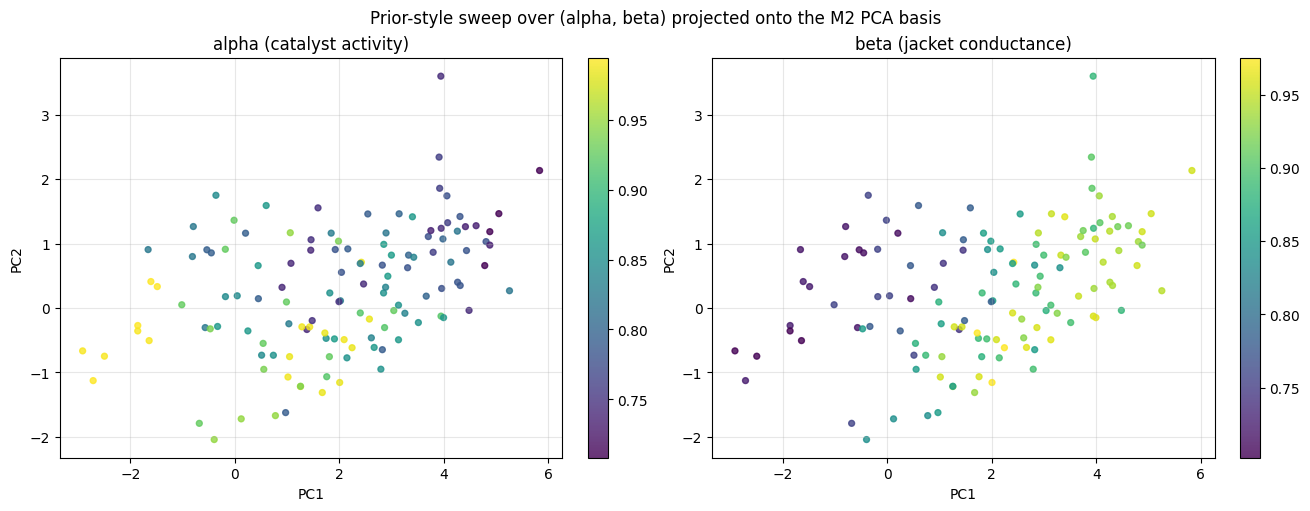

In [11]:
RUN_PRIOR_SWEEP = True
if RUN_PRIOR_SWEEP:
    from cstr_sbi.physics import (
        K0_NOMINAL, NOMINAL_CTRL, NOMINAL_INLET_CL, UA_NOMINAL,
    )
    from cstr_sbi.simulator import generate_replicates, warm_start_ic

    N_GRID = 32
    REPS = 4
    rng = np.random.default_rng(1)
    grid_alpha = rng.uniform(0.7, 1.0, size=N_GRID)
    grid_beta = rng.uniform(0.7, 1.0, size=N_GRID)

    all_S = []
    all_a = []
    all_b = []
    master_key = jax.random.PRNGKey(123)
    for i, (a, b) in enumerate(zip(grid_alpha, grid_beta)):
        params = jnp.array([UA_NOMINAL, K0_NOMINAL, float(a), float(b)])
        y0 = warm_start_ic(params, NOMINAL_INLET_CL, NOMINAL_CTRL)
        k = jax.random.fold_in(master_key, i)
        _, obs = generate_replicates(
            params, NOMINAL_INLET_CL, NOMINAL_CTRL, y0,
            n_replicates=REPS, master_key=k, t_window=60.0,
        )
        S_i = np.asarray(compute_summary_statistics_batch(obs, t))
        all_S.append(S_i)
        all_a.extend([float(a)] * REPS)
        all_b.extend([float(b)] * REPS)
    Z_prior = scaler.transform(np.vstack(all_S))
    Y_pca_prior = pca.transform(Z_prior)
    print(f"prior sweep: {Z_prior.shape[0]} windows over {N_GRID} (alpha,beta) draws")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    for ax, c, title in [
        (axes[0], np.asarray(all_a), "alpha (catalyst activity)"),
        (axes[1], np.asarray(all_b), "beta (jacket conductance)"),
    ]:
        sc = ax.scatter(Y_pca_prior[:, 0], Y_pca_prior[:, 1], c=c, cmap="viridis", s=18, alpha=0.8)
        ax.set(xlabel="PC1", ylabel="PC2", title=title)
        ax.grid(alpha=0.3)
        fig.colorbar(sc, ax=ax)
    fig.suptitle("Prior-style sweep over (alpha, beta) projected onto the M2 PCA basis")
    fig.savefig(FIGS / "03_pca_prior_sweep.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    print("prior sweep skipped")

## 9. M3 acceptance summary

* `cstr_sbi.summaries.compute_summary_statistics` produces a **29-D** feature
  vector: 20 per-channel base stats + 4 final-window means + 3 control
  aggregates + 2 physics-informed features (`UA_eff_proxy`, `k0_eff_proxy`)
  added after the M5 identifiability finding. NaN-tolerant; vmappable.
* Both PCA and t-SNE place the four closed-loop faults (Sc2, 3, 4, 5), the
  drift scenario (Sc7), and the two open-loop scenarios (Sc0, Sc6) in
  visibly distinguishable regions of the 2-D plane. Cross-validated LDA
  accuracy on the full 29-D feature vector is ≫ chance (1/8 = 12.5 %).
* The 2-feature `physics` subset (`UA_eff_proxy`, `k0_eff_proxy`) alone
  achieves ~98% LDA accuracy — directly encoding the identifiable products
  β·UA and α·k0.
* The top-10 mutual-information feature shortlist (29-D) is persisted to
  `data/03_feature_shortlist_29d.json`.

Next: **M4 — SBI training** (`04_sbi_training.ipynb`), using these features
and a 4-D `BoxUniform` prior on `[UA, k0, alpha, beta]`.